In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [3]:
iris.data.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
iris.target.head(5)

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


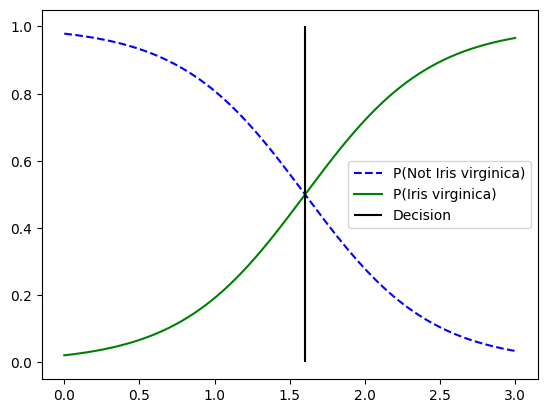

1.6036036036036037


In [7]:
X_new = np.linspace(0,3,1000).reshape(-1,1)
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:,1] >= 0.5][0,0]
plt.plot(X_new, y_proba[:, 0], "b--", label = "P(Not Iris virginica)")
plt.plot(X_new, y_proba[:, 1], "g", label = "P(Iris virginica)")
plt.vlines(decision_boundary, 0, 1, colors="k", label="Decision")
plt.legend()
plt.show()

print(decision_boundary)

In [10]:
iris_bunch = iris[0] if isinstance(iris, tuple) else iris

X = iris_bunch.data[["petal length (cm)", "petal width (cm)"]].to_numpy()
y = iris_bunch.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

x_sample = np.array([[5.0, 2.0]])
print(softmax_reg.predict(x_sample))
print(softmax_reg.predict_proba(x_sample).round(2))

[2]
[[0.   0.04 0.96]]
